In [1]:
from random import sample

#0. 작업 준비
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils import data
from torchvision import datasets,transforms, utils
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision.datasets import FashionMNIST

USE_MPS = torch.backends.mps.is_available()
DEVICE=torch.device('mps' if USE_MPS else 'cpu')

In [2]:
tr_ds=datasets.MNIST(root='./data/',
                     train=True,
                     download=True,
                     transform=transforms.Compose([transforms.ToTensor()]))

In [3]:
BATCH_SIZE=60000
tr_ds_loader=torch.utils.data.DataLoader(
    dataset=tr_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)
img,_=next(iter(tr_ds_loader))
img.shape
img.mean(),img.std()

(tensor(0.1307), tensor(0.3081))

In [4]:
BATCH_SIZE=64
EPOCHS=10

In [5]:
# 데이터 수정 (노이즈 삽입)
# 1. 데이터 준비
transform=transforms.Compose([
    #transforms.RandomHorizontalFlip(),#데이터 증강(노이즈삽입)
    transforms.ToTensor(),#입력 데이터 정리
    #transforms.Normalize((0.1307,),(0.3081,))
])#데이터 사용 방식 내용 결정
tr_ds_loader=torch.utils.data.DataLoader(
    datasets.MNIST('./data/',
        train=True,
        download=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
tt_ds_loader=torch.utils.data.DataLoader(
    datasets.MNIST('./data/',
        train=False,
        transform=transform
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [6]:
class 모델(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder=nn.Sequential(
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,12),
            nn.ReLU(),
            nn.Linear(12,3)
            )
        self.decoder=nn.Sequential(
            nn.Linear(3,12),
            nn.ReLU(),
            nn.Linear(12,64),
            nn.ReLU(),
            nn.Linear(64,128),
            nn.ReLU(),
            nn.Linear(128,28*28),
            nn.Sigmoid()
            )
    def forward(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return encoded,decoded

In [7]:
autoencoder=모델().to(DEVICE)
opt=optim.Adam(autoencoder.parameters(),lr=0.005)
criterion=nn.MSELoss()

In [8]:
v_img=tr_ds.data[:5].view(-1,28*28)
v_img=v_img.type(torch.FloatTensor)/255.
v_img.shape

torch.Size([5, 784])

In [9]:
def train(m,tr_ds_loader):
    m.train()
    for i,(x,y) in enumerate(tr_ds_loader):
        data=x.view(-1,28*28).to(DEVICE)
        target=x.view(-1,28*28).to(DEVICE)
        label=y.to(DEVICE)

        encoded,decoded=m(data)

        loss=criterion(decoded,target)
        opt.zero_grad()
        loss.backward()
        opt.step()

1회


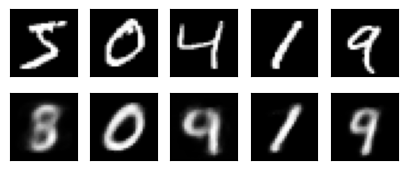

2회


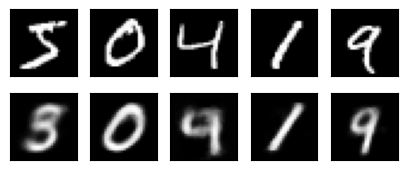

3회


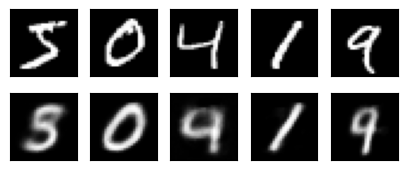

4회


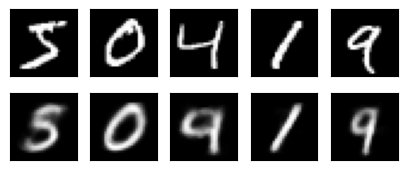

5회


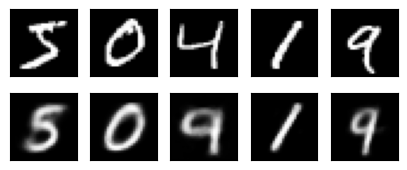

6회


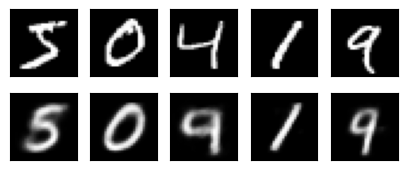

7회


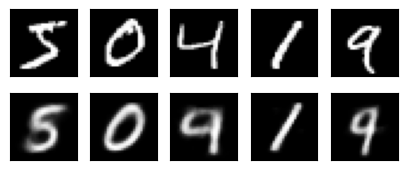

8회


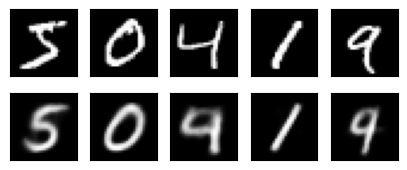

9회


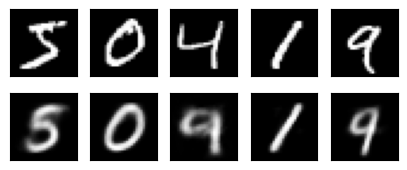

10회


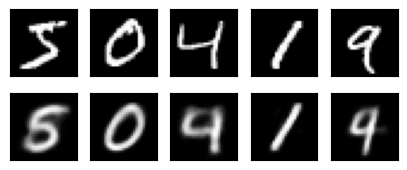

In [10]:
for epoch in range(1,EPOCHS+1):
    train(autoencoder,tr_ds_loader)

    tt_x=v_img.to(DEVICE)
    _,dc_data=autoencoder(tt_x)

    fig,a=plt.subplots(2,5,figsize=(5,2))
    print(f'{epoch}회')
    for i in range(5):
        img=v_img.data.numpy()[i].reshape(28,28)
        a[0][i].imshow(img,cmap='gray')
        a[0][i].set_xticks(())
        a[0][i].set_yticks(())
    for i in range(5):
        img=dc_data.to('cpu').data.numpy()[i].reshape(28,28)
        a[1][i].imshow(img,cmap='gray')
        a[1][i].set_xticks(())
        a[1][i].set_yticks(())
    plt.show()

# 패션 MNIST 데이터를 이용하여 오토인코더를 설계하고 학습하시오

1회


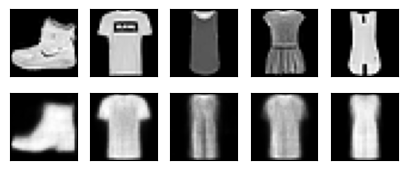

2회


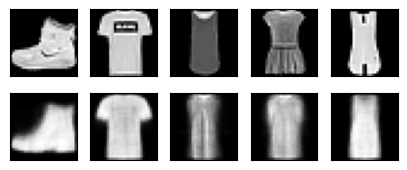

3회


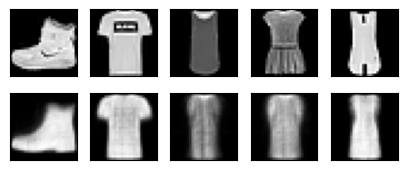

4회


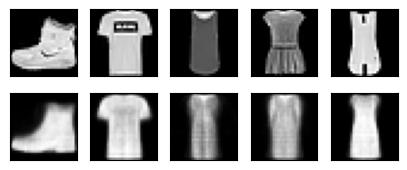

5회


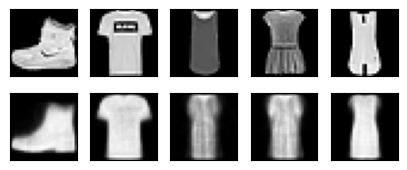

6회


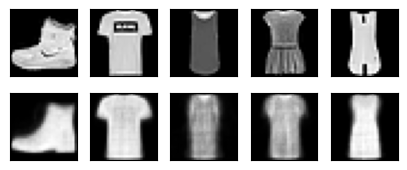

7회


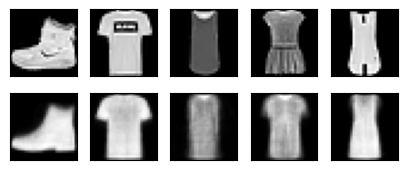

8회


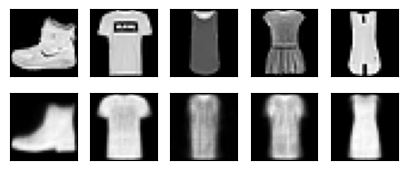

9회


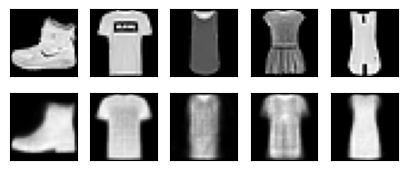

10회


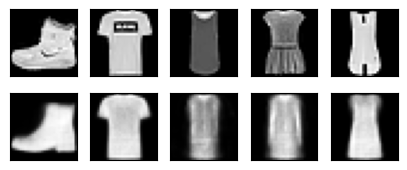

In [18]:
tr_ds = datasets.FashionMNIST(root='./data/',
                       train=True,
                       download=True,
                       transform=transforms.Compose([transforms.ToTensor()]))
BATCH_SIZE = 60000
tr_ds_loader = torch.utils.data.DataLoader(
    dataset=tr_ds,
    batch_size=BATCH_SIZE,
    shuffle=False
)
img, _ = next(iter(tr_ds_loader))
img.shape
img.mean(), img.std()
BATCH_SIZE = 64
EPOCHS = 10
# 데이터 수정 (노이즈 삽입)
# 1. 데이터 준비
transform = transforms.Compose([
    #transforms.RandomHorizontalFlip(),#데이터 증강(노이즈삽입)
    transforms.ToTensor(),  #입력 데이터 정리
    #transforms.Normalize((0.1307,),(0.3081,))
])  #데이터 사용 방식 내용 결정
tr_ds_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data/',
                   train=True,
                   download=False,
                   transform=transform
                   ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)
tt_ds_loader = torch.utils.data.DataLoader(
    datasets.FashionMNIST('./data/',
                   train=False,
                   transform=transform
                   ),
    batch_size=BATCH_SIZE,
    shuffle=True
)


class 모델(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)
        )
        self.decoder = nn.Sequential(
            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded


autoencoder = 모델().to(DEVICE)
opt = optim.Adam(autoencoder.parameters(), lr=0.005)
criterion = nn.MSELoss()
v_img = tr_ds.data[:5].view(-1, 28 * 28)
v_img = v_img.type(torch.FloatTensor) / 255.
v_img.shape


def train(m, tr_ds_loader):
    m.train()
    for i, (x, y) in enumerate(tr_ds_loader):
        data = x.view(-1, 28 * 28).to(DEVICE)
        target = x.view(-1, 28 * 28).to(DEVICE)
        label = y.to(DEVICE)

        encoded, decoded = m(data)

        loss = criterion(decoded, target)
        opt.zero_grad()
        loss.backward()
        opt.step()


for epoch in range(1, EPOCHS + 1):
    train(autoencoder, tr_ds_loader)

    tt_x = v_img.to(DEVICE)
    _, dc_data = autoencoder(tt_x)

    fig, a = plt.subplots(2, 5, figsize=(5, 2))
    print(f'{epoch}회')
    for i in range(5):
        img = v_img.data.numpy()[i].reshape(28, 28)
        a[0][i].imshow(img, cmap='gray')
        a[0][i].set_xticks(())
        a[0][i].set_yticks(())
    for i in range(5):
        img = dc_data.to('cpu').data.numpy()[i].reshape(28, 28)
        a[1][i].imshow(img, cmap='gray')
        a[1][i].set_xticks(())
        a[1][i].set_yticks(())
    plt.show()

In [20]:
tr_ds = FashionMNIST('./data/', train=True,download=True,transform=transforms.Compose([transforms.ToTensor()]))
tr_ds_loader = torch.utils.data.DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)

In [21]:
autoencoder=모델().to(DEVICE)
opt = optim.Adam(autoencoder.parameters(),lr=0.005)
criterion = nn.MSELoss()

In [22]:
def add_noise(img):
    noise = torch.randn(img.size())*0.2
    noise_img = img+noise
    return noise_img

In [23]:
def train(m,tr_ds_loader):
    m.train()
    avg_loss = 0
    for i,(x,y) in enumerate(tr_ds_loader):
        noise_img = add_noise(x)
        data=noise_img.view(-1,28*28).to(DEVICE)
        target=x.view(-1,28*28).to(DEVICE)
        label=y.to(DEVICE)

        encoded,decoded=m(data)

        loss=criterion(decoded,target)
        opt.zero_grad()
        loss.backward()
        opt.step()

        avg_loss += loss.item()
    return avg_loss/len(tr_ds_loader)

In [24]:
for epoch in range(1, EPOCHS + 1):
    loss = train(autoencoder, tr_ds_loader)
    print(f'{epoch}회, loss:{loss}')

1회, loss:0.03685337398995532
2회, loss:0.025773722388501615
3회, loss:0.024343680433515928
4회, loss:0.023683540391991897
5회, loss:0.023395787527375637
6회, loss:0.023085953657831084
7회, loss:0.022859627245935297
8회, loss:0.02268930884606358
9회, loss:0.02249253009841132
10회, loss:0.022456402808967938


In [25]:
tt_ds = FashionMNIST('./data/', train=False,download=False,transform=transforms.Compose([transforms.ToTensor()]))
tt_ds_loader = torch.utils.data.DataLoader(tt_ds, batch_size=BATCH_SIZE, shuffle=True)
sample_data = tt_ds.data[0].view(-1, 28*28)
sample_data = sample_data.type(torch.FloatTensor) / 255.
oj_data = sample_data[0]
noise_data = add_noise(oj_data).to(DEVICE)
_,output = autoencoder(noise_data)

In [29]:
output.size(), oj_data.size(), noise_data.size()

(torch.Size([784]), torch.Size([784]), torch.Size([784]))

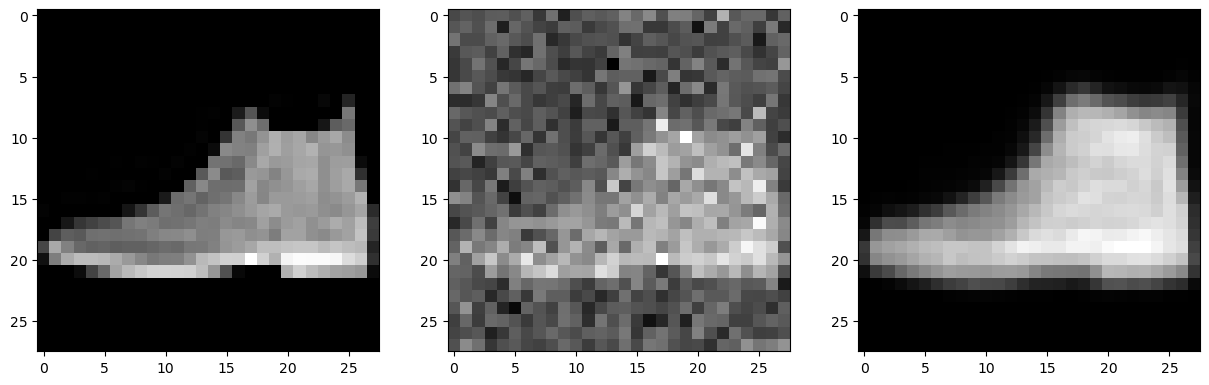

In [32]:
fig, a = plt.subplots(1,3,figsize=(15,15))
oj_img = oj_data.to('cpu').data.numpy().reshape(28, 28)
noisy_img = noise_data.to('cpu').data.numpy().reshape(28, 28)
out_img = output.to('cpu').data.numpy().reshape(28, 28)

print(oj_img.shape, noisy_img.shape, out_img.shape)

a[0].imshow(oj_img, cmap='gray')
a[1].imshow(noisy_img, cmap='gray')
a[2].imshow(out_img, cmap='gray')